## Решение обратной задачи электростатики

In [52]:
from numpy import linspace, logspace, zeros, exp, linalg, dot, eye
from matplotlib.pyplot import figure, axes, style, show
import matplotlib.pyplot as plt
import numpy as np

Задаём матрицу системы

<center>$
A = \begin{pmatrix}
\displaystyle\frac{(s_1-x_0)h}{2((s_1-x_0)^2+l_y^2+l_z^2)^{3/2}} & \displaystyle\frac{(s_1-x_1)h}{((s_1-x_1)^2+l_y^2+l_z^2)^{3/2}} & \cdots & \displaystyle\frac{(s_1-x_N)h}{2((s_1-x_N)^2+l_y^2+l_z^2)^{3/2}} \\
\displaystyle\frac{l_y h}{2((s_1-x_0)^2+l_y^2+l_z^2)^{3/2}} & \displaystyle\frac{l_y h}{((s_1-x_1)^2+l_y^2+l_z^2)^{3/2}} & \cdots & \displaystyle\frac{l_y h}{2((s_1-x_N)^2+l_y^2+l_z^2)^{3/2}} \\
\displaystyle\frac{l_z h}{2((s_1-x_0)^2+l_y^2+l_z^2)^{3/2}} & \displaystyle\frac{l_z h}{((s_1-x_1)^2+l_y^2+l_z^2)^{3/2}} & \cdots & \displaystyle\frac{l_z h}{2((s_1-x_N)^2+l_y^2+l_z^2)^{3/2}} \\[5 mm]
\displaystyle\frac{(s_2-x_0)h}{2((s_2-x_0)^2+l_y^2+l_z^2)^{3/2}} & \displaystyle\frac{(s_2-x_1)h}{((s_2-x_1)^2+l_y^2+l_z^2)^{3/2}} & \cdots & \displaystyle\frac{(s_2-x_N)h}{2((s_2-x_N)^2+l_y^2+l_z^2)^{3/2}} \\
\displaystyle\frac{l_y h}{2((s_2-x_0)^2+l_y^2+l_z^2)^{3/2}} & \displaystyle\frac{l_y h}{((s_2-x_1)^2+l_y^2+l_z^2)^{3/2}} & \cdots & \displaystyle\frac{l_y h}{2((s_2-x_N)^2+l_y^2+l_z^2)^{3/2}} \\
\displaystyle\frac{l_z h}{2((s_2-x_0)^2+l_y^2+l_z^2)^{3/2}} & \displaystyle\frac{l_z h}{((s_2-x_1)^2+l_y^2+l_z^2)^{3/2}} & \cdots & \displaystyle\frac{l_z h}{2((s_2-x_N)^2+l_y^2+l_z^2)^{3/2}} \\[5 mm]
\cdots & \cdots & \cdots & \cdots \\[5 mm]
\displaystyle\frac{(s_{N-1}-x_0)h}{2((s_{N-1}-x_0)^2+l_y^2+l_z^2)^{3/2}} & \displaystyle\frac{(s_{N-1}-x_1)h}{((s_{N-1}-x_1)^2+l_y^2+l_z^2)^{3/2}} & \cdots & \displaystyle\frac{(s_{N-1}-x_N)h}{2((s_{N-1}-x_N)^2+l_y^2+l_z^2)^{3/2}} \\
\displaystyle\frac{l_y h}{2((s_{N-1}-x_0)^2+l_y^2+l_z^2)^{3/2}} & \displaystyle\frac{l_y h}{((s_{N-1}-x_1)^2+l_y^2+l_z^2)^{3/2}} & \cdots & \displaystyle\frac{l_y h}{2((s_{N-1}-x_N)^2+l_y^2+l_z^2)^{3/2}} \\
\displaystyle\frac{l_z h}{2((s_{N-1}-x_0)^2+l_y^2+l_z^2)^{3/2}} & \displaystyle\frac{l_z h}{((s_{N-1}-x_1)^2+l_y^2+l_z^2)^{3/2}} & \cdots & \displaystyle\frac{l_z h}{2((s_{N-1}-x_N)^2+l_y^2+l_z^2)^{3/2}} \\
\end{pmatrix}
$</center>

In [53]:
def system_matrix(N, x, h, N_s, s, l_y, l_z) :
    A = zeros((3*N_s, N+1))

    for j in range(0, 3*N_s, 3):
        A[j,0] = 1/2*(s[int(j/3)] - x[0])*h/((s[int(j/3)] - x[0])**2 + l_y**2 + l_z**2)**3/2
        for n in range(1, N) :
            A[j,n] = (s[int(j/3)] - x[n])*h/((s[int(j/3)] - x[n])**2 + l_y**2 + l_z**2)**3/2
            A[j,N] = 1/2*(s[int(j/3)] - x[N])*h/((s[int(j/3)] - x[N])**2 + l_y**2 + l_z**2)**3/2

    for j in range(1, 3*N_s, 3):
        A[j,0] = 1/2*l_y*h/((s[int((j-1)/3)] - x[0])**2 + l_y**2 + l_z**2)**3/2
        for n in range(1,N) :
            A[j,n] = l_y*h/((s[int((j-1)/3)] - x[n])**2 + l_y**2 + l_z**2)**3/2
            A[j,N] = 1/2*l_y*h/((s[int((j-1)/3)] - x[N])**2 + l_y**2 + l_z**2)**3/2

    for j in range(2, 3*N_s, 3) :
        A[j,0] = 1/2*l_z*h/((s[int((j-2)/3)] - x[0])**2 + l_y**2 + l_z**2)**3/2
        for n in range(1, N) :
            A[j,n] = l_z*h/((s[int((j-2)/3)] - x[n])**2 + l_y**2 + l_z**2)**3/2
            A[j,N] = 1/2*l_z*h/((s[int((j-2)/3)] - x[N])**2 + l_y**2 + l_z**2)**3/2

    return A

Задаём непрерывную (реальную) модель распределения плотности
<center>
$\rho (x) = \displaystyle\frac{2e^{2(x - 0.382)}}{0.009}+\displaystyle\frac{1.2e^{-2(x-0.618)}}{0.018}$
</center>

In [54]:
# Истинное распределение плотности (мы его не знаем)
def rho_model(x) :
    return 2*exp(-(x- 0.382)**2/0.009) + 1.2*exp(-(x- 0.618)**2/0.018)

# Высчитываем значение РЕАЛЬНОГО распределения плотности на заданной сетке
a = 0.; b = 1.

N_model = 100

h_model = (b - a) / N_model
x_model = linspace(a, b, N_model + 1)

X_model= zeros(N_model + 1)
for n in range(N_model + 1) :
    X_model[n] = rho_model(x_model[n])

Подготавливаем правую часть системы $B$, т.е. ту, которую мы измеряем в эксперименте

In [55]:
# Границы сенсоров (c и d по координате x) и фиксируем координаты y и z (задача одномерная)
c = -1.; d = 2.
l_y= 0.8 ; l_z= 0.2

# Количество сенсоров и разбиваем отрезок на сетку
N_s= 200
x_s = linspace(c, d, N_s)

# Модельное A
A = system_matrix(N_model, x_model, h_model, N_s, x_s, l_y, l_z)

# "Измеренное B"
B = dot(A,X_model)

Минимизируем функционал $F[X]={\| {AX-B} \|}^2 + \alpha { \| {X} \| }^2$. Т.к. параметр регуляризации не задан, то для каждого $\alpha _i$ некоторого набора $\alpha$ будем минимизировать функциолнал методом сопряженных градиентов

$X_{inv}$ - это подходящая нам функция (набор значений функции на сетке), при которой достигается миниум функционала Тихонова

<center> $X_{inv} = (A^T A + \alpha E)^{-1} A^T B$ </center>

In [56]:
N = 20
h = (b - a) / N
x = linspace(a, b, N+1)

A = system_matrix(N, x, h, N_s, x_s, l_y, l_z)

alpha = 10**(-13)
X_inv = linalg.solve(dot(A.T,A) + alpha*eye(N+1),dot(A.T,B))

Изобразим решение для $\alpha = 10^{-13}$

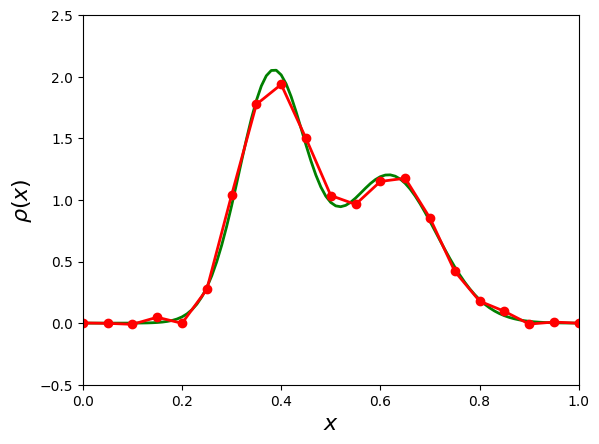

In [59]:
# Отрисовка решения
plt.style.use('default')

fig = figure()
ax = axes(xlim=(a,b), ylim=(-0.5,2.5))
ax.set_xlabel(r'$x$', fontsize=16); ax.set_ylabel(r'$\rho (x)$', fontsize=16)
ax.plot(x_model,X_model,'-g',lw=2)
ax.plot(x,X_inv,'-or',lw=2)
show()

Зададим ошибку $\delta = 10^{-14}$

In [78]:
delta = 10**(-2)

Зададим интервал $\alpha = (10^{-6}, 10^{6})$ и посчитаем на $50$ точках значение функционала $\rho(\alpha)= \| {AX-B} \| ^ 2 - \delta^2$

In [79]:
rho = list()
alphas = logspace(-6, 6, 50)

for a in alphas:
    X_inv = linalg.solve(dot(A.T,A) + a*eye(N+1),dot(A.T,B))
    rho.append(linalg.norm(dot(A, X_inv) - B)**2  - delta**2)

rho = np.array(rho)

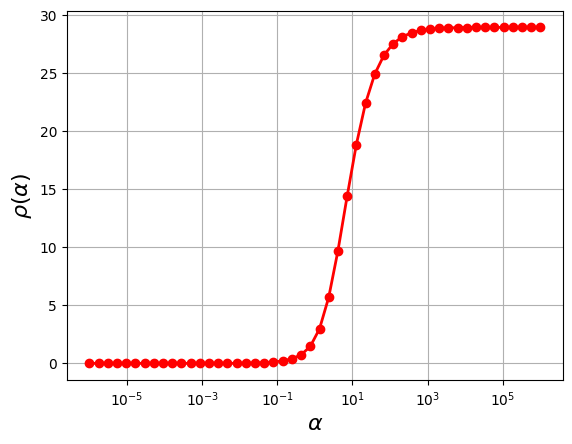

In [80]:
plt.figure()

plt.plot(alphas, rho, '-or', lw=2)

plt.xscale('log')   # логарифмическая ось alpha
plt.xlabel(r'$\alpha$', fontsize=16)          # alpha как LaTeX
plt.ylabel(r'$\rho(\alpha)$', fontsize=16)    # rho(alpha) как LaTeX

plt.grid(True)

plt.show()